#**Abdul Ahad Qureshi**

# Task 1: Load, Explore & Clean the Data
In this task, we load the Telco Customer Churn dataset, handle structural anomalies (like text in numeric columns), and visualize the balance of the target variable (Churn)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Data Shape ---
(7043, 21)

--- Initial Missing Values ---
0

Missing values in TotalCharges after conversion: 11

--- Churn Class Balance ---
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


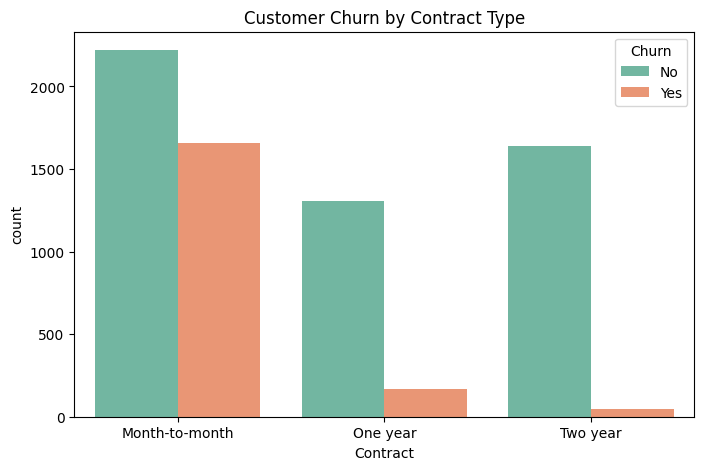

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the dataset from the Colab folder in Drive
# Note: If your folder is named exactly "Colab Notebooks", use this path.
# If it is named differently (e.g., "colab"), adjust the path accordingly.
file_path = '/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_path)

# 3. Explore the initial state
print("--- Data Shape ---")
print(df.shape)
print("\n--- Initial Missing Values ---")
print(df.isnull().sum().sum())

# 4. Clean 'TotalCharges'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"\nMissing values in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")
df.dropna(subset=['TotalCharges'], inplace=True)

# 5. Check class balance
print("\n--- Churn Class Balance ---")
print(df['Churn'].value_counts(normalize=True) * 100)

# 6. Visualize Churn vs Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Customer Churn by Contract Type')
plt.show()

# Task 2: Preprocess for a Neural Network
Neural networks require strictly numerical inputs, meaning all text-based categorical columns must be encoded. We use One-Hot Encoding (via pd.get_dummies) for most categorical columns (like PaymentMethod) because they are nominal categories with no inherent mathematical order. For binary columns (like Churn), we use simple Label/Binary encoding mapping them to 0 and 1. We also scale the continuous numeric features so the neural network converges efficiently.

In [4]:
# 1. Drop useless identifier column
df.drop('customerID', axis=1, inplace=True)

# 2. Encode binary categorical target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Handle binary inputs vs multi-class inputs
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}) # Map accordingly

# 4. One-Hot Encode remaining nominal categorical columns
nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# 5. Scale numeric features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# 6. Train-Test Split
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training features shape: {X_train.shape}")

Training features shape: (5625, 30)


# Task 3: Build & Train a Baseline Model
Here we establish a baseline Keras Sequential model using two hidden Dense layers. We will compile it using standard binary classification parameters (adam optimizer and binary_crossentropy loss).

Training Baseline Model...
Baseline Test Accuracy: 0.7598


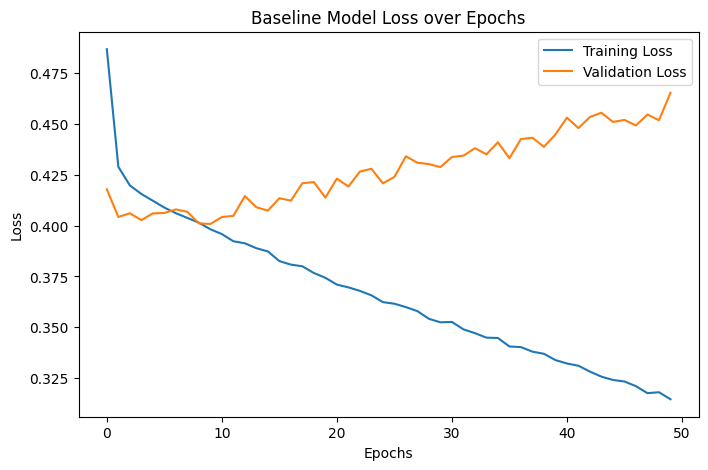

In [5]:
# 1. Build Baseline Model
baseline_model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary output (0 to 1 probability)
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Train the Baseline Model
print("Training Baseline Model...")
history_base = baseline_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0 # Suppress spam, we will plot the curves instead
)

# 3. Evaluate Baseline
base_loss, base_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Test Accuracy: {base_acc:.4f}")

# 4. Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(history_base.history['loss'], label='Training Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Task 4: Tune Your Model
Looking at the baseline loss curves, standard dense networks are highly prone to overfitting the training data over many epochs. To combat this, we implement two tuning techniques from our labs:  Dropout Layers (Rate = 0.3): Randomly deactivates 30% of neurons during training to prevent the model from memorizing specific data paths.Early Stopping: Monitors the validation loss and stops training automatically if it fails to improve for 10 consecutive epochs (patience=10), restoring the best weights rather than the final weights.

In [6]:
# 1. Build Tuned Model with Dropout
tuned_model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3), # Tuning Technique 1
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

tuned_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Define Early Stopping Callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,        # Tuning Technique 2
    restore_best_weights=True
)

# 3. Train Tuned Model
print("Training Tuned Model...")
history_tuned = tuned_model.fit(
    X_train, y_train,
    epochs=100, # Safely setting high epochs since early stopping will catch it
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

# 4. Compare Results
tuned_loss, tuned_acc = tuned_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Test Accuracy: {base_acc:.4f}")
print(f"Tuned Test Accuracy:    {tuned_acc:.4f}")

Training Tuned Model...
Baseline Test Accuracy: 0.7598
Tuned Test Accuracy:    0.8003


# Task 5: Evaluate Properly
Accuracy alone is misleading for this dataset because the target variable (Churn) is imbalanced (~73% No, ~27% Yes). A naive "dummy" model that guesses "No Churn" for every single customer would score 73% accuracy without actually identifying a single churn risk. Precision, recall, and F1-score provide a much more honest assessment of the model's ability to find the minority class.

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



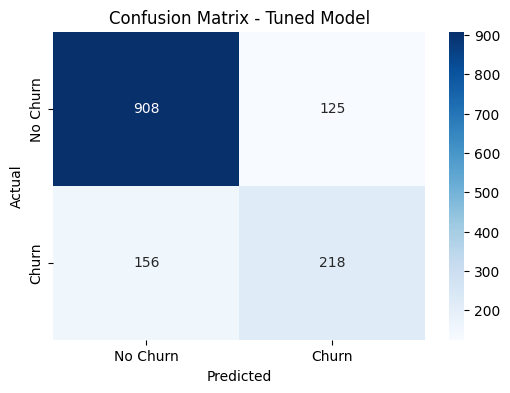

In [7]:
# Generate predictions (probabilities > 0.5 become 1, else 0)
y_pred_probs = tuned_model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# 1. Classification Report (Precision, Recall, F1)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Tuned Model')
plt.show()

# Task 6: Save & Predict
We will export the trained Keras model so it can be deployed into a production environment without needing to see the historical training data again.

In [10]:
# 1. Save the model
tuned_model.save('churn_tuned_model.keras')
print("Model saved to disk as 'churn_tuned_model.keras'")

# Convert and save as TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(tuned_model)
tflite_model = converter.convert()

with open('churn_tuned_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("Model saved to disk as 'churn_tuned_model.tflite'")

# 2. Prediction Function
def predict_new_customer(features_array):
    """
    Loads the saved model and predicts churn probability for a preprocessed feature array.
    """
    loaded_model = keras.models.load_model('churn_tuned_model.keras')

    # Predict probability
    prob = loaded_model.predict(features_array, verbose=0)[0][0]
    prediction = "Will Churn" if prob > 0.5 else "Will Not Churn"

    return f"Prediction: {prediction} (Probability: {prob:.1%})"

# 3. Test on a hypothetical customer (using the first row of our processed test set as a mock)
# Reshape to (1, number_of_features) which is the batch format Keras expects
hypothetical_customer = X_test.iloc[0].values.reshape(1, -1).astype(np.float32) # Convert to float32

result = predict_new_customer(hypothetical_customer)
print("\nHypothetical Customer Test:")
print(result)

Model saved to disk as 'churn_tuned_model.keras'
Saved artifact at '/tmp/tmp8ij41r6d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135097116832784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135097116834512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135097116834704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135097116831056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135097116835472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135097116831824: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model saved to disk as 'churn_tuned_model.tflite'

Hypothetical Customer Test:
Prediction: Will Not Churn (Probability: 2.3%)


A Convolutional Neural Network (CNN) is best used for analyzing grid-like or spatial data, primarily imagery, because its filters are designed to capture local geometric patterns like edges and textures; an example use case is detecting plant diseases from photos of crop leaves. In contrast, a Recurrent Neural Network (RNN) is designed for sequential or temporal data where the order of inputs fundamentally dictates the meaning; an example use case is predicting stock market prices based on a time-series of previous daily financial closures.